# **Sales Analysis**

In [19]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [20]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [21]:
sales_df = pd.read_csv(
    'dataset/processed/ecommerce_processed.csv',
    parse_dates=['order_date']
)

In [22]:
sales_df.sample(10)

,order_date,order_year,order_month,order_day_of_week,part_day,is_weekend,customer_name,gender,age,age_group,customer_segment,country,order_status,category,sub_category,unit_price_usd,price_tier,quantity,quantity_segment,gross_revenue_usd,discount_amount_usd,discount_percent,discount_tier,is_discounted,revenue_usd,order_value_segment,profit_usd,profit_margin_percent,payment_method,shipping_method,shipping_cost_usd,shipping_cost_percent,delivery_days,delivery_speed,shipping_country,shipment_type,rating,customer_loyalty_score,loyalty_tier,coupon_used,session_duration_min,engagement_level,pages_visited,abandoned_cart_before,fraud_risk_score,fraud_risk_level,device_type,campaign_source,traffic_source
282563,2025-06-07 15:19:37.108871,2025,6,Sat,Afternoon,Yes,Carl Bell,Male,67,65+,Premium,Australia,Completed,Clothing,Mens Wear,53.68,Mid-Range,1,Single,53.68,8.05,15,Medium Discount,Yes,45.63,Low,16.32,35.77,Apple Pay,Economy,17.60,38.57,2,Fast,Australia,Domestic,5,98.70,High,Yes,4.70,Low,18,Yes,19.70,Low,Desktop,Organic,Direct
187493,2025-05-26 12:38:32.487730,2025,5,Mon,Afternoon,No,Taylor Morris,Male,36,35-44,Regular,Belgium,Completed,Clothing,Accessories,63.16,Mid-Range,2,Small Basket,126.32,0.00,0,No Discount,No,126.32,Medium,46.06,36.46,Credit Card,Economy,13.83,10.95,13,Slow,Belgium,Domestic,4,35.60,Medium,No,9.80,Low,2,Yes,33.20,Medium,Tablet,Organic,Search
219584,2024-04-21 14:13:19.998517,2024,4,Sun,Afternoon,Yes,Amanda Sullivan,Female,47,45-54,Regular,Germany,Pending,Electronics,Tablets,12.85,Budget,2,Small Basket,25.70,0.00,0,No Discount,No,25.70,Low,15.02,58.44,Apple Pay,Next Day,0.09,0.35,5,Standard,Germany,Domestic,3,25.70,Low,Yes,16.00,Medium,8,Yes,42.00,Medium,Desktop,Organic,Direct
188288,2024-09-14 22:50:54.911099,2024,9,Sat,Evening,Yes,Nicole Hall,Female,41,35-44,Regular,Belgium,Completed,Electronics,Accessories,431.41,Luxury,3,Small Basket,"1,294.23",129.42,10,Low Discount,Yes,"1,164.81",Very High,640.29,54.97,Credit Card,Next Day,10.57,0.91,14,Slow,Belgium,Domestic,5,74.10,High,Yes,37.10,Medium,20,No,57.00,Medium,Desktop,Affiliate,Direct
145586,2025-04-26 22:52:12.928393,2025,4,Sat,Evening,Yes,Robert Campbell,Male,55,55-64,Premium,France,Completed,Home,Furniture,99.18,Mid-Range,5,Bulk,495.90,74.39,15,Medium Discount,Yes,421.51,High,191.41,45.41,Debit Card,Express,24.10,5.72,5,Standard,France,Domestic,4,60.70,Medium,Yes,55.20,High,8,No,55.30,Medium,Mobile,Email,Referral
13308,2025-07-27 14:21:00.891137,2025,7,Sun,Afternoon,Yes,Tony Barton,Male,40,35-44,Regular,Italy,Completed,Sports,Sports Wear,233.99,Luxury,5,Bulk,"1,169.95",0.00,0,No Discount,No,"1,169.95",Very High,491.20,41.98,Bank Transfer,Standard,22.62,1.93,11,Slow,Italy,Domestic,4,53.00,Medium,No,39.30,Medium,5,No,32.10,Medium,Tablet,Instagram,Referral
651387,2024-12-25 14:55:08.845533,2024,12,Wed,Afternoon,No,Robert Thompson,Male,21,18-24,Premium,Italy,Completed,Sports,Accessories,179.95,Premium,1,Single,179.95,26.99,15,Medium Discount,Yes,152.96,Medium,43.20,28.24,Debit Card,Express,15.08,9.86,6,Standard,Italy,Domestic,5,76.10,High,Yes,59.30,High,6,Yes,73.10,High,Tablet,Organic,Social
20004,2025-03-03 20:10:21.984906,2025,3,Mon,Evening,No,Joseph Perkins,Male,52,45-54,Regular,France,Completed,Home,Appliances,275.98,Luxury,2,Small Basket,551.96,55.20,10,Low Discount,Yes,496.76,High,198.14,39.89,Apple Pay,Standard,15.99,3.22,5,Standard,France,Domestic,4,26.30,Low,No,13.00,Low,4,No,23.30,Low,Desktop,Organic,Search
497877,2025-07-22 12:41:52.941041,2025,7,Tue,Afternoon,No,Rhonda Williams,Female,59,55-64,Premium,Germany,Processing,Health,Personal Care,164.23,Premium,5,Bulk,821.15,123.17,15,Medium Discount,Yes,697.98,Very High,156.58,22.43,Debit Card,Next Day,16.98,2.43,12,Slow,Germany,Domestic,3,25.60,Low,Yes,18.00,Medium,8,No,17.70,Low,Tablet,Organic,Search
921850,2025-07-11 01:45:19.633388,2025,7,Fri,Night,No,Mary Davis,Female,41,35-44,Premium,Belgium,Completed,Sports,Accessories,206.85,Luxury,1,Single,206.85,0.00,0,No Discount,No,206.85,Medium,90.45,43.73,B

## 1.1 Revenue by Time

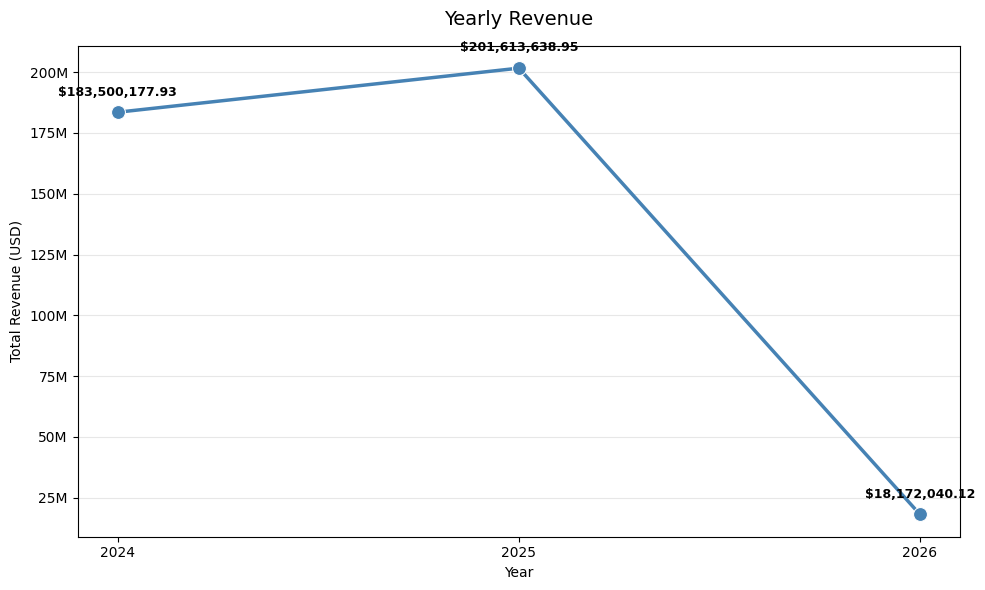

In [23]:
# 1.1.1 Yearly Revenue

yearly_revenue = (
    sales_df.groupby('order_year')['revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_revenue,
    x='order_year',
    y='revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

# Add value labels on each marker
for x, y in zip(yearly_revenue['order_year'], yearly_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',              
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Yearly Revenue', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Revenue (USD)')
plt.xticks(yearly_revenue['order_year'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

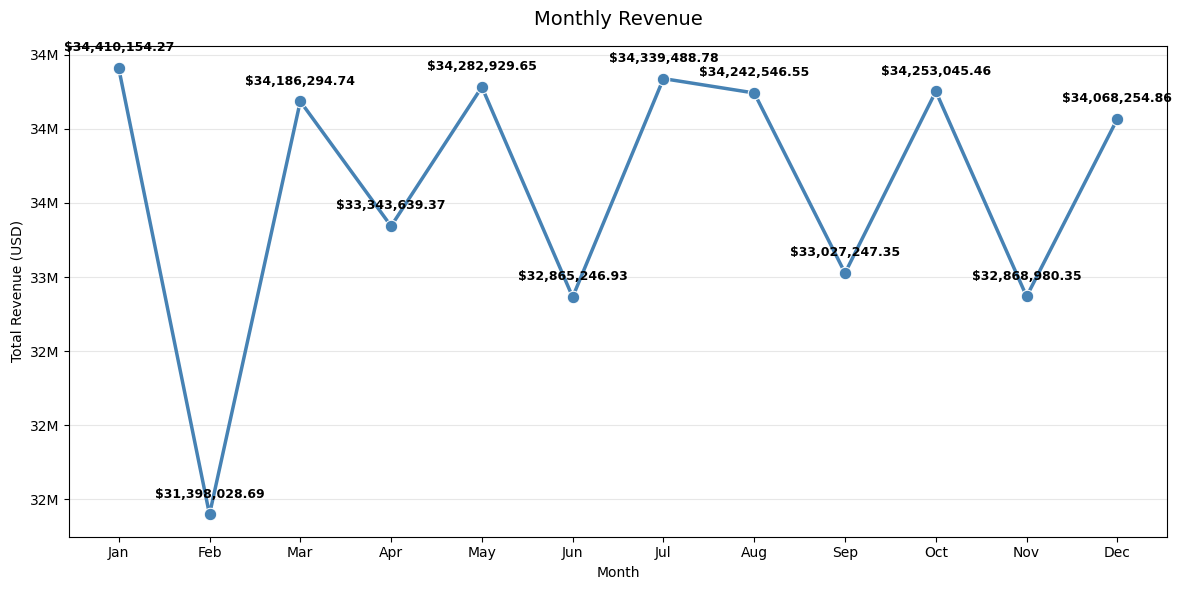

In [24]:
# 1.1.2 Monthly Revenue

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_map = {i+1: m for i, m in enumerate(month_order)}

sales_df['order_month'] = sales_df['order_month'].map(month_map)

monthly_revenue = (
    sales_df.groupby('order_month')['revenue_usd']
    .sum()
    .reindex(month_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_revenue,
    x='order_month',
    y='revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue'
)

for x, y in zip(monthly_revenue['order_month'], monthly_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Monthly Revenue', fontsize=14, pad=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

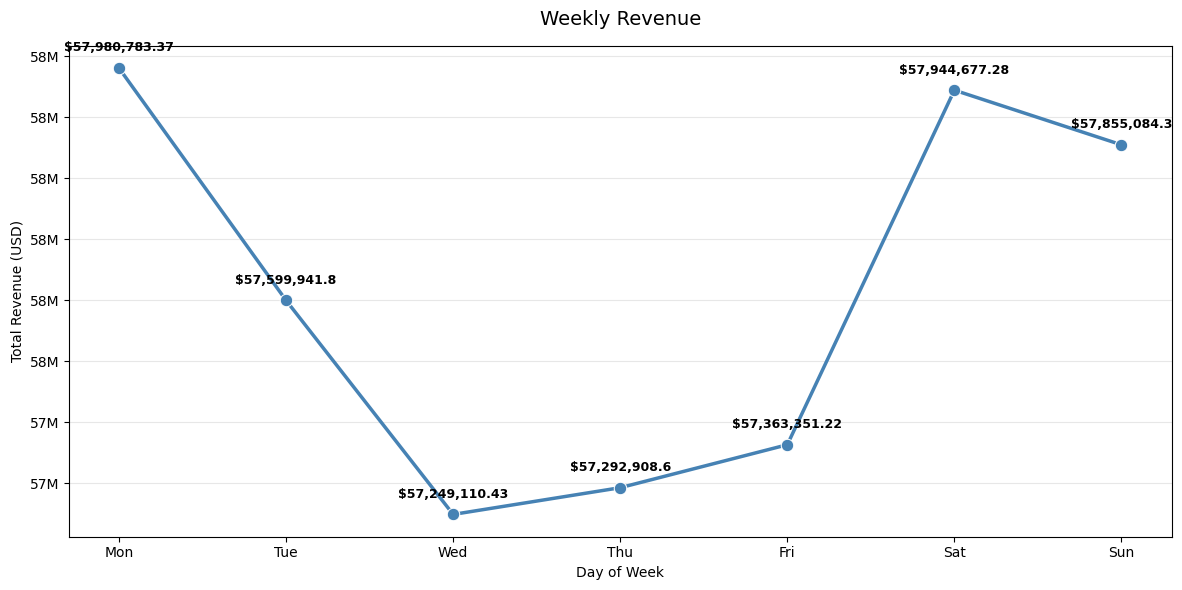

In [25]:
# 1.1.3 Day of Week Revenue

day_of_week_revenue = (
    sales_df.groupby('order_day_of_week')['revenue_usd']
    .sum()
    .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=day_of_week_revenue,
    x='order_day_of_week',
    y='revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue',
)

for x, y in zip(day_of_week_revenue['order_day_of_week'], day_of_week_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Weekly Revenue', fontsize=14, pad=15)
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

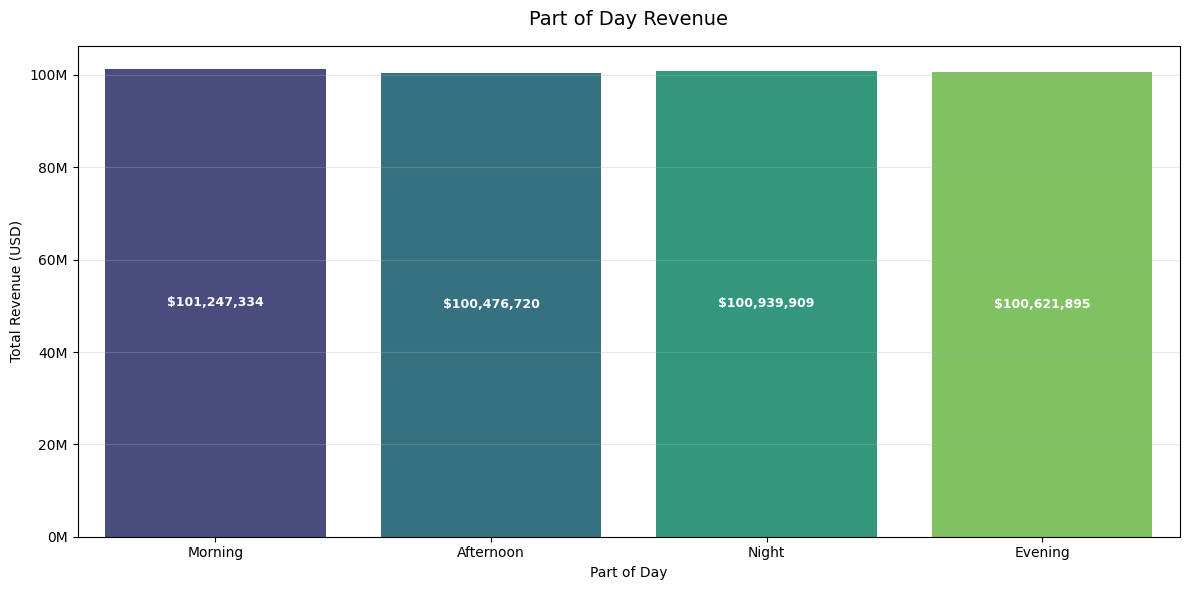

In [26]:
# 1.1.4 Part of Day Revenue

part_day_revenue = (
    sales_df.groupby('part_day')['revenue_usd']
    .sum()
    .reindex(['Morning', 'Afternoon', 'Night', 'Evening'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=part_day_revenue,
    x='part_day',
    y='revenue_usd',
    palette='viridis',
    hue='part_day',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Part of Day Revenue', fontsize=14, pad=15)
plt.xlabel('Part of Day')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

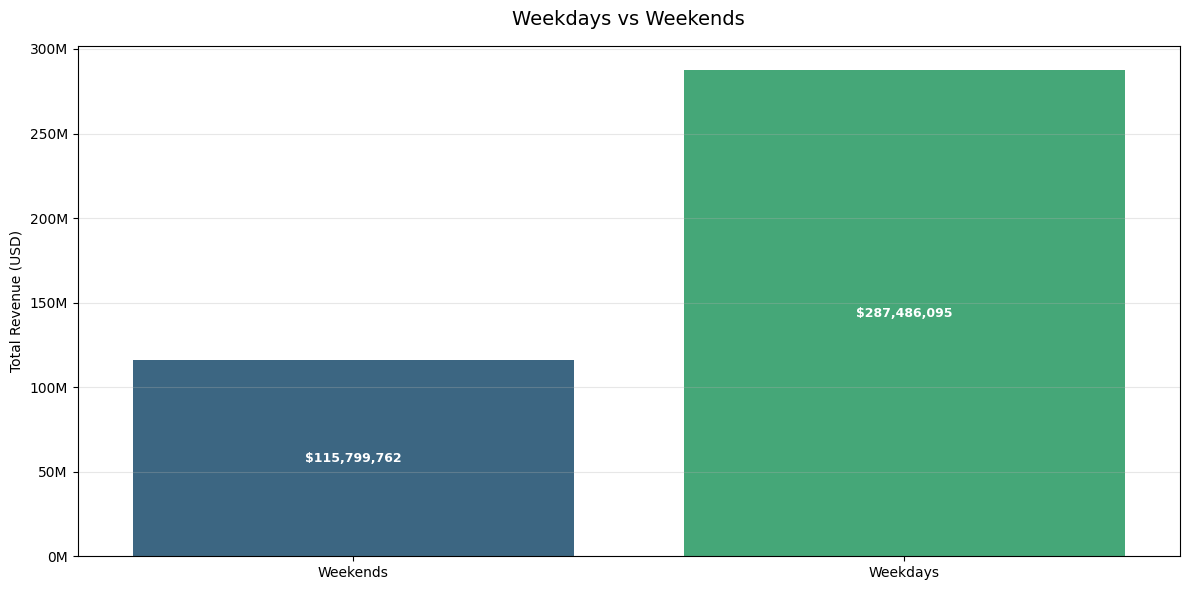

In [27]:
# 1.1.5 Weekend vs Weekedays

is_weekend_revenue = (
    sales_df.groupby('is_weekend')['revenue_usd']
    .sum()
    .reindex(['Yes', 'No'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=is_weekend_revenue,
    x='is_weekend',
    y='revenue_usd',
    palette='viridis',
    hue='is_weekend',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Weekdays vs Weekends', fontsize=14, pad=15)
plt.xlabel('')
plt.xticks([0, 1], ['Weekends', 'Weekdays'])
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.2 Revenue by Category and Sub-Category

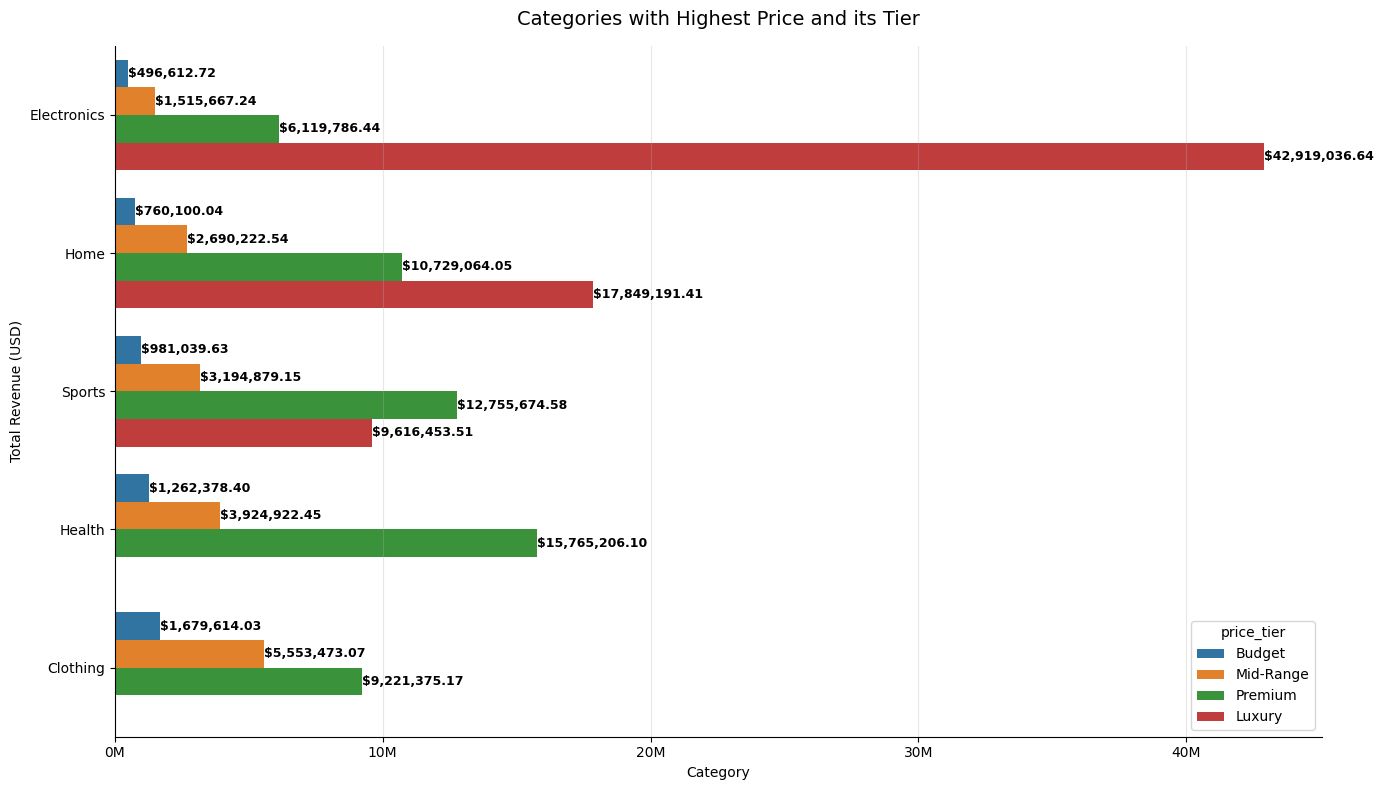

In [28]:
# Determine which categories has highest pricing and its tier

price_category = sales_df.groupby(
    ['category', 'price_tier']
)['unit_price_usd'].sum().reset_index().sort_values('unit_price_usd')

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=price_category,
    x='unit_price_usd',
    y='category',
    hue='price_tier',
    palette='tab10',
    orient='h'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Categories with Highest Price and its Tier', fontsize=14, pad=15)
plt.xlabel('Category')
plt.ylabel('Total Revenue (USD)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

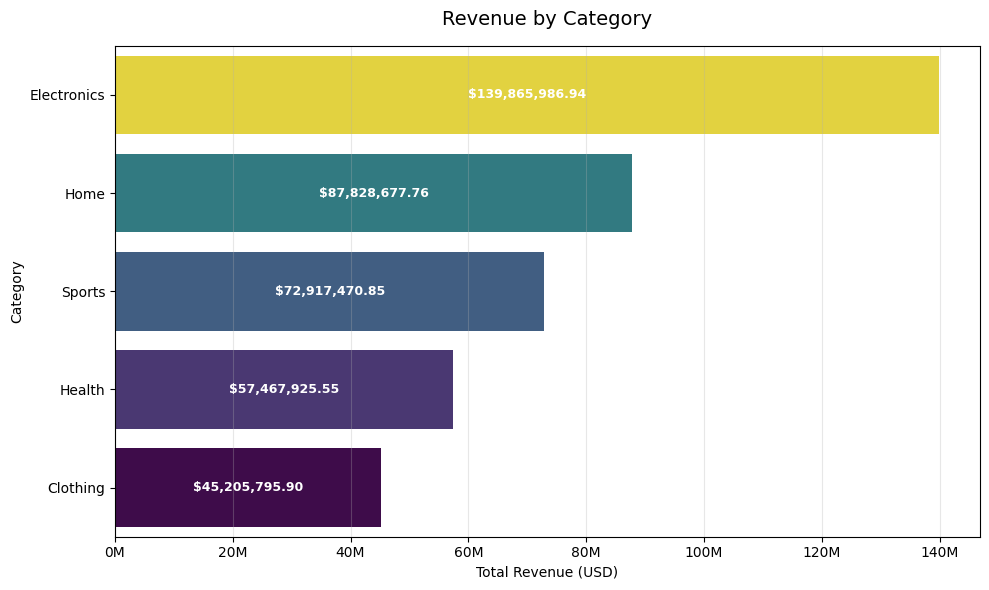

In [29]:
# 1.2.1 Revenue per Category

category_revenue = (
    sales_df.groupby('category')['revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_revenue,
    x='revenue_usd',
    y='category',
    palette='viridis',
    orient='h',
    hue='revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Revenue by Category', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

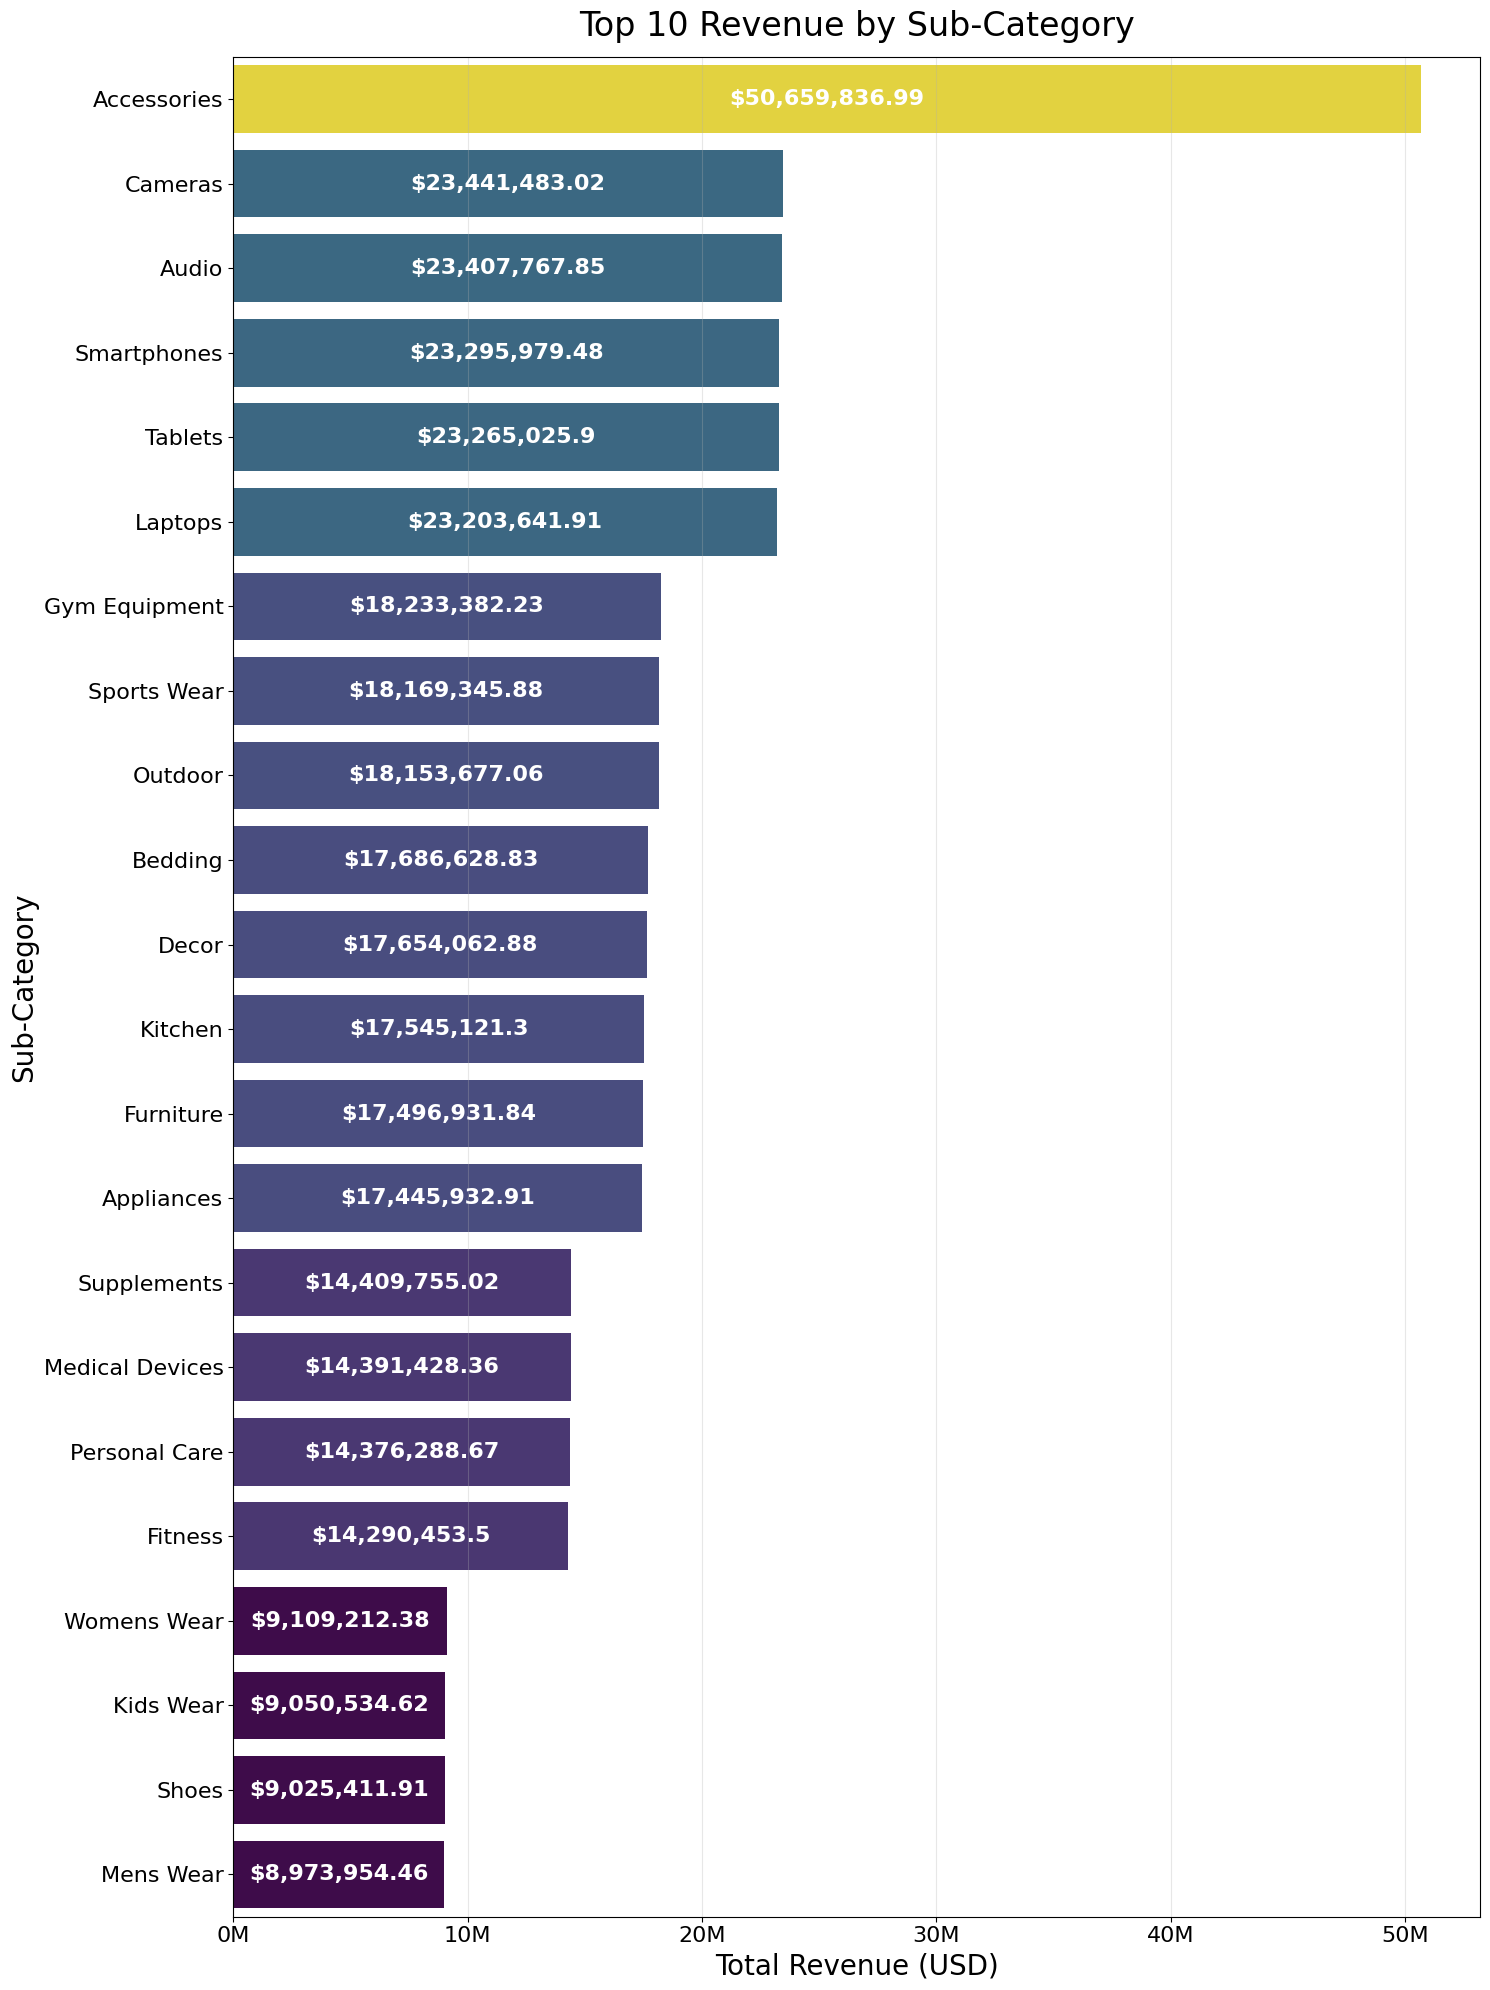

In [30]:
# 1.2.1 Top 10 Revenue Sub Category

subcategory_revenue = (
    sales_df.groupby('sub_category')['revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(15, 20))

ax = sns.barplot(
    data=subcategory_revenue,
    x='revenue_usd',
    y='sub_category',
    palette='viridis',
    orient='h',
    hue='revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=16,
        fontweight='bold'
    )
    

plt.title('Top 10 Revenue by Sub-Category', fontsize=24, pad=15)
plt.xlabel('Total Revenue (USD)', fontsize=20)
plt.ylabel('Sub-Category', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.3 Revenue by Country

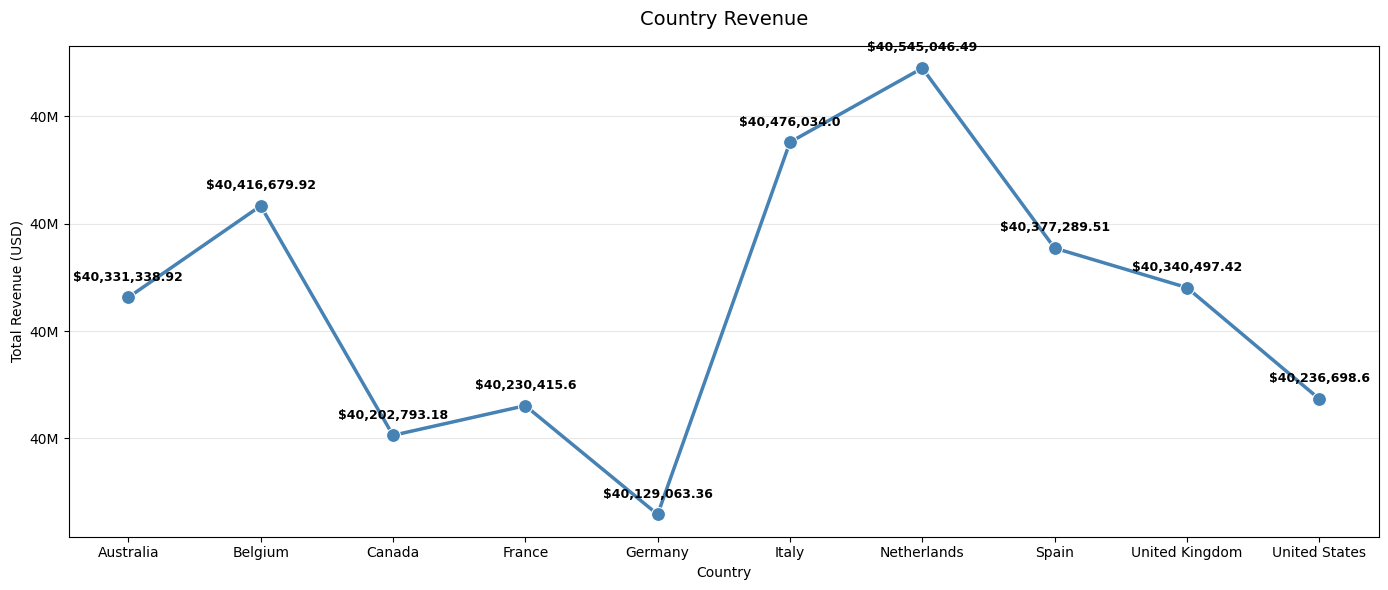

In [31]:
# 1.3.1 Country Revenue

country_revenue = (
    sales_df.groupby('country')['revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    data=country_revenue,
    x='country',
    y='revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

# Add value labels on each marker
for x, y in zip(country_revenue['country'], country_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',              
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Country Revenue', fontsize=14, pad=15)
plt.xlabel('Country')
plt.ylabel('Total Revenue (USD)')
plt.xticks(country_revenue['country'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

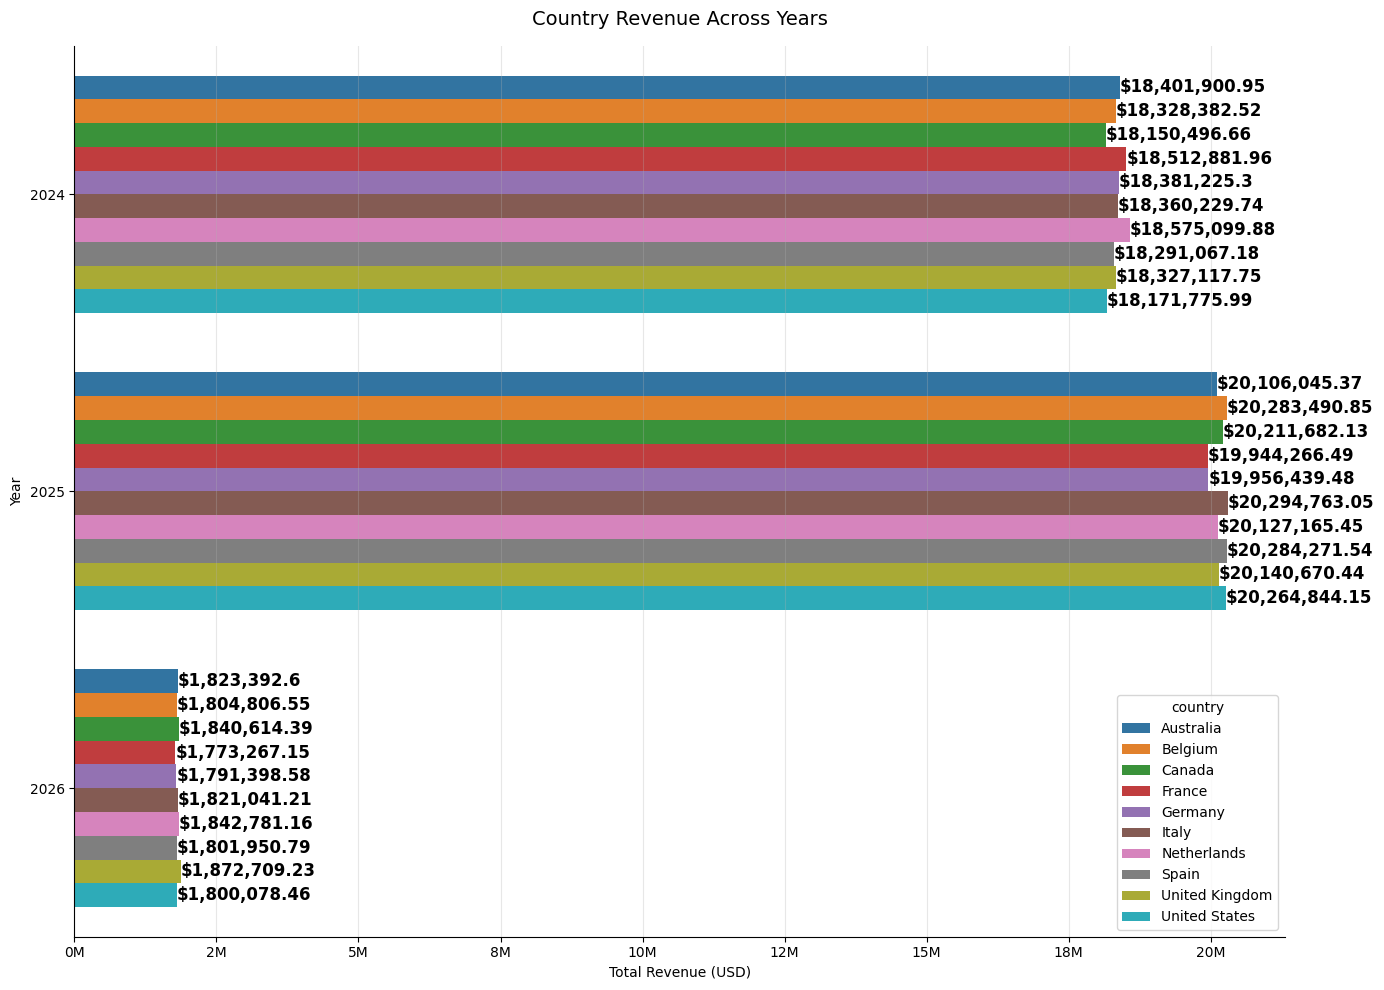

In [32]:
# 1.3.1 Country Revenue Across Years

country_yearly_revenue = sales_df.groupby(
    ['order_year', 'country']
)['revenue_usd'].sum().reset_index()

plt.figure(figsize=(14, 10))

ax = sns.barplot(
    data=country_yearly_revenue,
    x='revenue_usd',
    y='order_year',
    palette='tab10',
    hue='country',
    orient='h'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold',
    )
    

plt.title('Country Revenue Across Years', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Year')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.4 Revenue by Order Value Segment

C:\Users\User\AppData\Local\Temp\ipykernel_23176\426723021.py:16: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  ax = sns.barplot(


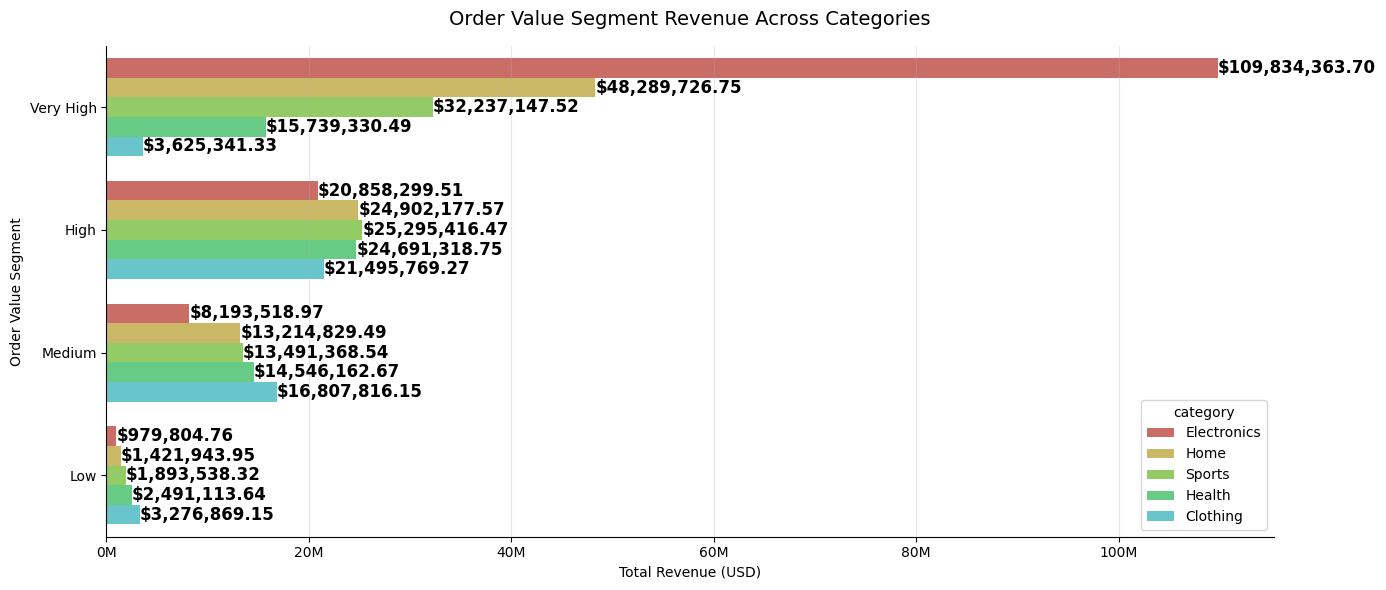

In [33]:
# 1.4.1 Order Value Segment Revenue Across Categories

order_value_segment_revenue = sales_df.groupby(
    ['order_value_segment', 'category']
)['revenue_usd'].sum().reset_index().sort_values('revenue_usd')


order_value_segment_revenue['order_value_segment'] = pd.Categorical(
    order_value_segment_revenue['order_value_segment'],
    categories=['Very High', 'High', 'Medium', 'Low'],
    ordered=True
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=order_value_segment_revenue,
    x='revenue_usd',
    y='order_value_segment',
    hue='category',
    palette=sns.color_palette('hls',8),
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Order Value Segment Revenue Across Categories', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel("Order Value Segment")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.5 Customers

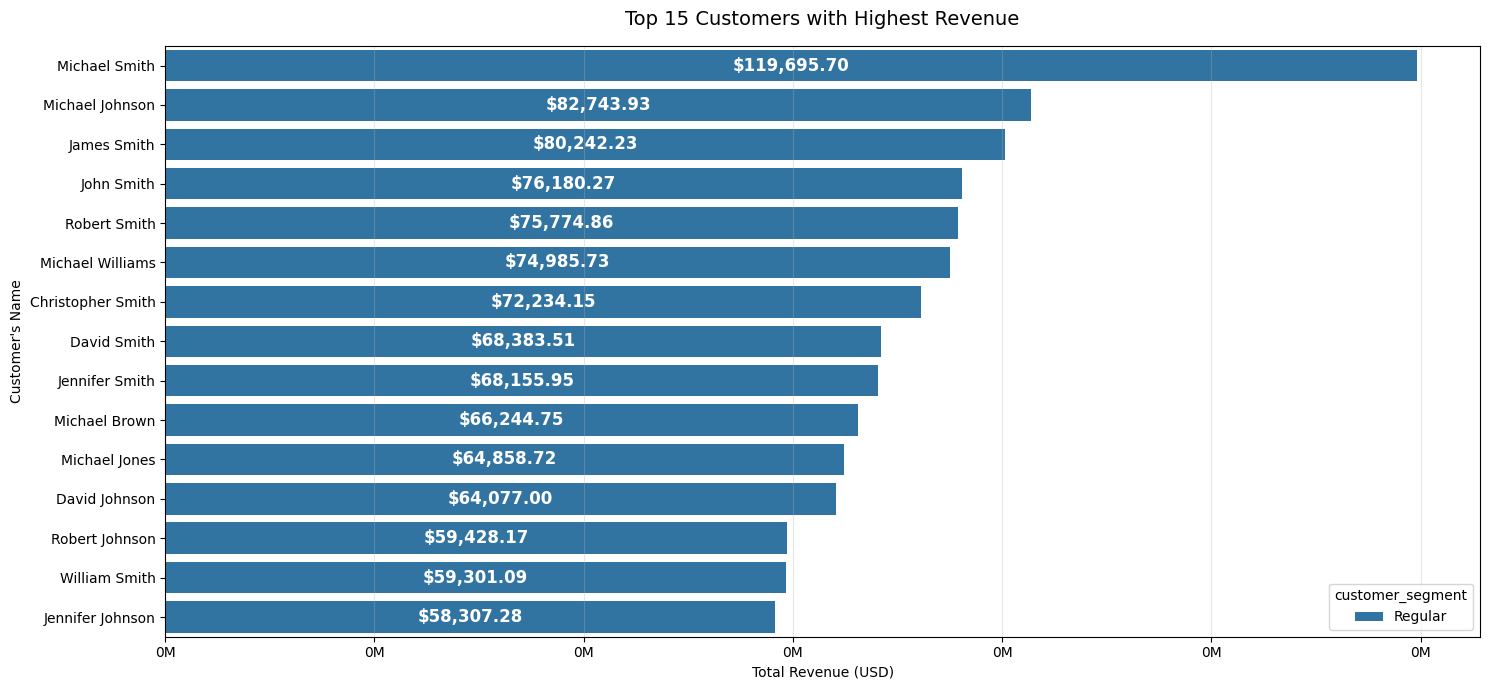

In [34]:
# 1.5.1 Top 15 Customers with Highest Revenue and their Customer Segment

customers_highest_revenue = sales_df.groupby(['customer_name','customer_segment'])['revenue_usd'].sum().reset_index().sort_values('revenue_usd', ascending=False).head(15)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=customers_highest_revenue,
    x='revenue_usd',
    y='customer_name',
    hue='customer_segment',
    orient='h',
    palette='tab10'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Top 15 Customers with Highest Revenue', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel("Customer's Name")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

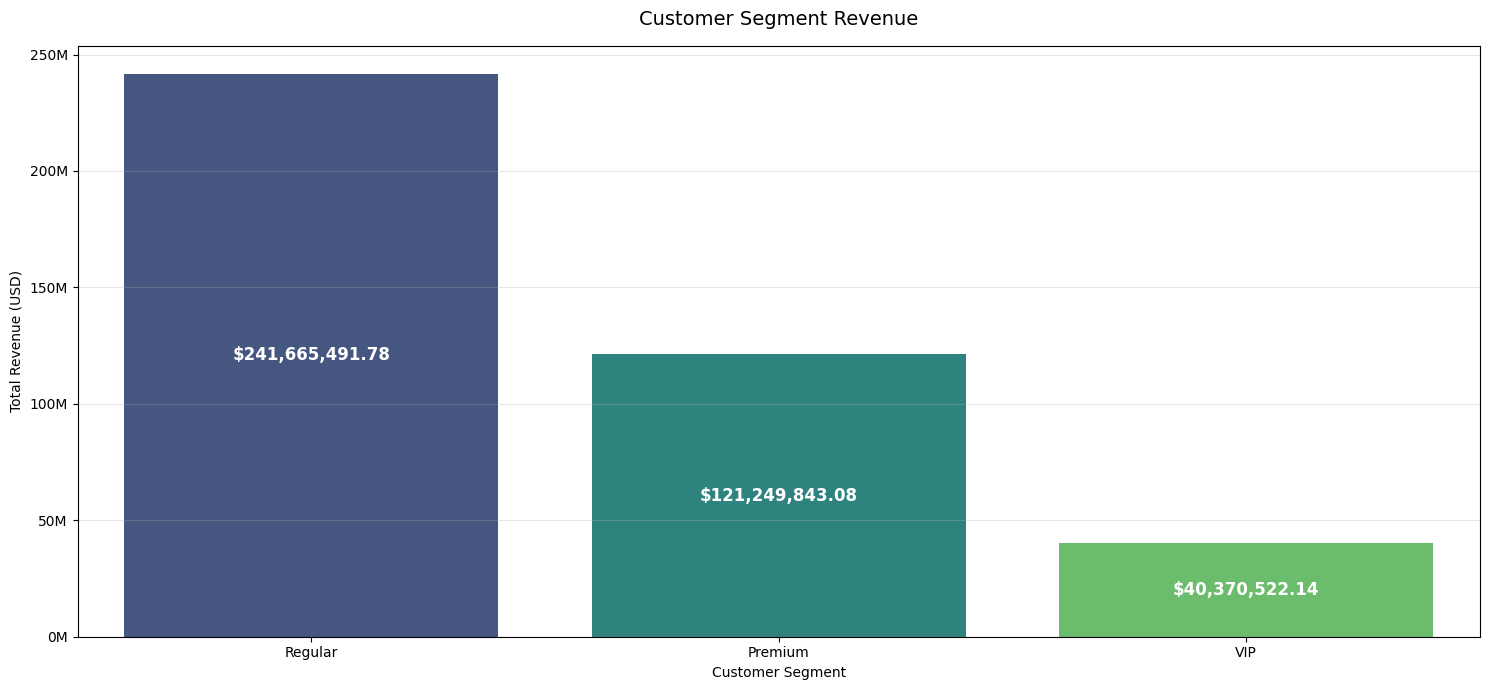

In [35]:
# 1.5.2 Customer Segment Revenue

customer_segment_revenue = sales_df.groupby('customer_segment')['revenue_usd'].sum().reset_index().sort_values('revenue_usd', ascending=False).head(15)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=customer_segment_revenue,
    x='customer_segment',
    y='revenue_usd',
    hue='customer_segment',
    legend=False,
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Customer Segment Revenue', fontsize=14, pad=15)
plt.xlabel('Customer Segment')
plt.ylabel("Total Revenue (USD)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.6 Gross Revenue (Without discount) vs Revenue (With discount applied)